In [1]:
%load_ext autoreload
%autoreload 2
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import (
    binned_statistic
)
from src.samples import(
    load_gpm_dyamond_features,
    load_gpm_dyamond_edge_frac_max_sweep
)
from src.plotting import (
    source_line_params
)
from src.saving import (
    save_figure
)

In [2]:
feature_stats_dict_0p05 = load_gpm_dyamond_features()
for name, df in feature_stats_dict_0p05.items():
    print(f"{name:>8}: {df.height:,} rows")

     GPM: 62,059 rows
    GEOS: 321,979 rows
    gSAM: 309,108 rows
    ICON: 628,422 rows
  SCREAM: 636,968 rows


# Plot CDFs of $P_{max}$

Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/Pmax_CDF.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/p95_bar_plot.pdf as PDF ...


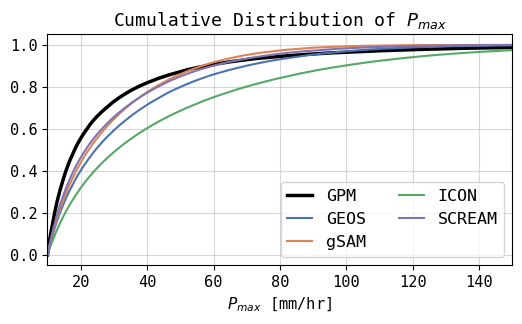

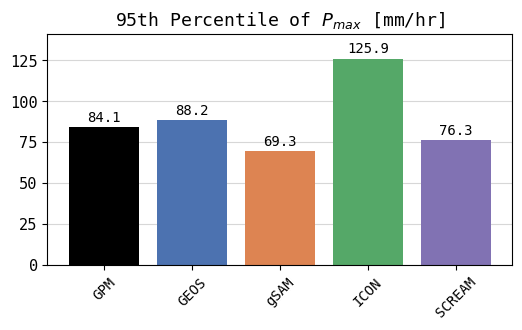

In [3]:
p95_stats = {}
fig, ax = plt.subplots(figsize=(6,3))

for source, df in feature_stats_dict_0p05.items():
    series = df['max_precip_mm_hr']
    p95_stats[source] = series.quantile(0.95)

    values = series.drop_nulls().sort().to_numpy()
    cdf = np.arange(1, len(values) + 1) / len(values)

    ax.plot(values, cdf, label=source, **source_line_params(source))

ax.set_xlim(10, 150)
ax.set_xlabel('$P_{max}$ [mm/hr]')
ax.legend(ncols=2)
ax.grid(alpha=0.5)
ax.set_title('Cumulative Distribution of $P_{max}$')
save_figure(fig, 'Pmax_CDF.pdf')


# Bar plot
fig, ax = plt.subplots(figsize=(6,3))
bars = ax.bar(
    list(p95_stats.keys()),
    list(p95_stats.values()),
    color=[source_line_params(s)['color'] for s in p95_stats]
)
ax.set_title('95th Percentile of $P_{max}$ [mm/hr]')
ax.grid(axis='y', alpha=0.5)
ax.set_axisbelow(True)
ax.bar_label(bars, fmt='%.1f', padding=2, fontsize=10)
ax.margins(y=0.12)
ax.tick_params(axis='x', labelsize=10, rotation=45)
save_figure(fig, 'p95_bar_plot.pdf')

# Size distribution

Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/PDF_PF_Area.pdf as PDF ...


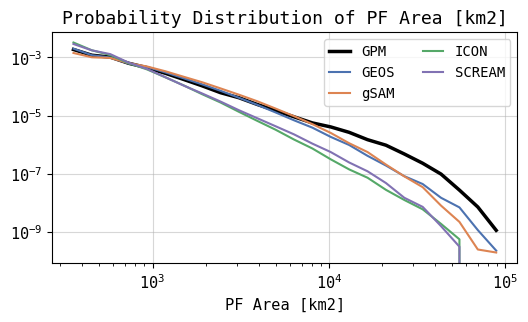

In [4]:
fig, ax = plt.subplots(figsize=(6,3))

for source, df in feature_stats_dict_0p05.items():
    series = df['area_km2']
    bins = np.logspace(2.5, 5.0, 25)
    values = series.drop_nulls().to_numpy()
    pdf, edges = np.histogram(values, bins=bins, density=True)
    bin_centers = np.sqrt(edges[:-1] * edges[1:])

    ax.plot(bin_centers, pdf, label=source, **source_line_params(source))

ax.set_xscale('log')
ax.set_yscale('log')

ax.legend(ncols=2, fontsize=10)
ax.grid(alpha=0.5)

ax.set_xlabel('PF Area [km2]')

ax.set_title('Probability Distribution of PF Area [km2]')
save_figure(fig, 'PDF_PF_Area.pdf')

# Sensitivity Sweeps

In [5]:
feature_stats_efm_sweep = load_gpm_dyamond_edge_frac_max_sweep()

Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/sensitivity_PF_Area_EFM_Sweep.pdf as PDF ...


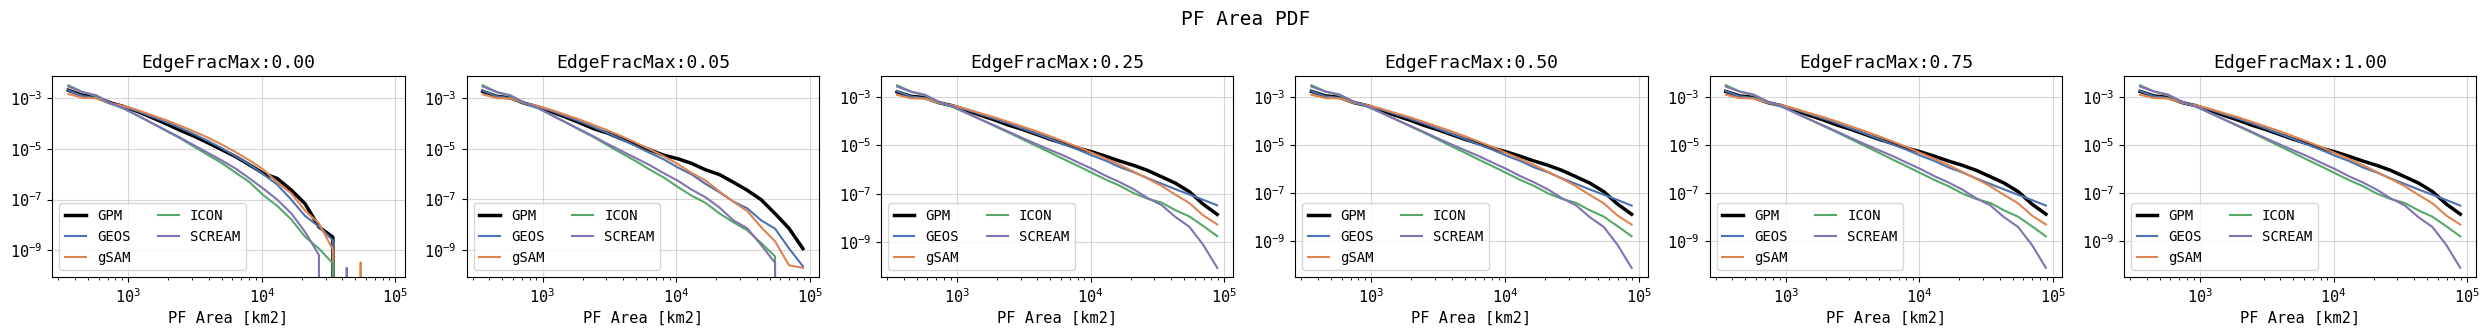

In [6]:
num_cols = len(feature_stats_efm_sweep.keys())
fig, axs = plt.subplots(ncols=num_cols, figsize=(25, 3))

for ax, (efm, feature_stats_dict) in zip(axs, feature_stats_efm_sweep.items()):
    for source, df in feature_stats_dict.items():
        series = df['area_km2']
        bins = np.logspace(2.5, 5.0, 25)
        values = series.drop_nulls().to_numpy()
        pdf, edges = np.histogram(values, bins=bins, density=True)
        bin_centers = np.sqrt(edges[:-1] * edges[1:])
    
        ax.plot(bin_centers, pdf, label=source, **source_line_params(source))
    
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.legend(ncols=2, fontsize=10)
        ax.grid(alpha=0.5)
        
        ax.set_xlabel('PF Area [km2]')
        ax.set_title(f'EdgeFracMax:{efm:.2f}')
fig.tight_layout(pad=1.0)
fig.suptitle('PF Area PDF', y=1.1, fontsize=14)
save_figure(fig, 'sensitivity_PF_Area_EFM_Sweep.pdf')